# ![Logotip de Spark](http://spark-mooc.github.io/web-assets/images/ta_Spark-logo-small.png)

# Activitat BATCH

## Sistema de fitxers HDFS i extracció de coneixement de fonts de dades heterogènies mitjançant RDDs

En aquesta pràctica començarem amb una breu introducció a HDFS (Hadoop Distributed File System), per entendre com s'emmagatzema i distribueix la informació. Després, ens endinsarem en Spark RDDs i  Spark SQL per processar grans volums de dades de manera eficient. Per finalitzar, treballarem amb dades relacionals i la seva gestió en entorns distribuïts.

### Puntuació de l'activitat:
- **Exercici 1**: Gestió i anàlisi de dades en HDFS *(0.25 punts)*
- **Exercici 2**: Manipulació de RDDs en PySpark *(0.75 punts)*
- **Exercici 3**: Anàlisi de Dades de Tweets en PySpark *(0.75 punts)*
- **Exercici 4**: Optimització de Càlculs amb Persistència *(0.25 punts)*
- **Exercici 5**: Anàlisi de Tweets mitjançant DataFrames i consultes SQL *(1.5 punts)*
- **Exercici 6**: Anàlisi de Tweets Geolocalitzats *(1.25 punts)*
- **Exercici 7**: Anàlisi del Patró d'Activitat Horària a Twitter *(1 punts)*
- **Exercici 8**: Anàlisi de la Relació entre Tweets i Diputats per Província *(0.75 punts)*
- **Exercici 9**: Anàlisi d'Interaccions de Retweets i Graus d'Usuari *(0.5 punts)*
- **Exercici 10**: Distribució del Grau de Sortida en una Xarxa de Retweets *(0.5 punts)*
- **Exercici 11**: Preguntes teòriques *(2.5 punts)*

# **HDFS (Hadoop Distributed File System)**

<img src="https://hadoop.apache.org/docs/r1.2.1/images/hadoop-logo.jpg">

**HDFS (Hadoop Distributed File System)** és una part essencial de l'ecosistema Big Data d'Apache Hadoop. HDFS està dissenyat per emmagatzemar i gestionar grans volums de dades distribuïdes en diversos nodes d'un clúster, proporcionant alta tolerància a fallades i escalabilitat. En aquest primer exercici, interactuarem amb HDFS mitjançant la línia de comandes dins de l'entorn de **JupyterLab**, el que ens permetrà familiaritzar-nos amb les operacions bàsiques d'aquest sistema de fitxers distribuït.

Per començar, és necessari obrir un terminal des de **JupyterLab**. Un cop obert, podem enviar comandes al sistema de fitxers HDFS, que són molt similars a les comandes de bash en entorns Linux. Algunes de les comandes d'HDFS que executarem començaran amb `hdfs dfs`, seguides de l'operació que desitgem realitzar. Per exemple, si volem llistar els fitxers i directoris en el directori arrel d'HDFS, utilitzarem la comanda ls de la següent manera:

In [3]:
!hdfs dfs -ls /

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.slf4j.impl.Reload4jLoggerFactory]
Found 21 items
drwxr-xr-x   - hdfs   hdfs            0 2025-07-22 16:13 /alluxio
drwxr-xr-x   - hdfs   hdfs            0 2025-07-21 11:29 /amshbase
drwxrwxrwt   - yarn   hadoop          0 2025-11-18 13:06 /app-logs
drwxr-xr-x   - hdfs   hdfs            0 2025-07-22 12:45 /apps
drwxr-xr-x   - yarn   hadoop          0 2025-07-21 11:32 /ats
drwxr-xr-x   - hdfs   hdfs            0 2025-07-21 11:32 /atsv2
drwxr-xr-x   - sgraul hdfs            0 2025-09-24 13:49 /aula_M2.858
drwxr-xr-x   - hdfs   hdfs            0 2025-0

És important que totes les comandes s'executin correctament en l'entorn **JupyterLab** per obtenir els resultats desitjats.

Per consultar la documentació completa de les comandes disponibles en HDFS, pots accedir a la guia oficial en el següent enllaç: [HDFS Command Guide](https://hadoop.apache.org/docs/current/hadoop-project-dist/hadoop-hdfs/HDFSCommands.html)

Al llarg d'aquest exercici, utilitzarem algunes de les comandes més comunes d'HDFS per realitzar operacions com la creació de directoris, la càrrega i descàrrega d'arxius, i la gestió de permisos, entre altres. A mesura que avancem, et familiaritzaràs amb l'estructura d'HDFS i com aprofitar les seves funcionalitats en entorns Big Data.

### **Exercici 1**: Gestió i anàlisi de dades a HDFS (*0.25 punts*)

En aquest exercici treballaràs amb un conjunt de registres de consum elèctric emmagatzemats en l'arxiu `consumo_hogar_2024.csv`, disponible a la ruta /aula_M2.858/data/consumo_hogar_2024.csv.

La teva tasca consisteix a realitzar una exploració completa de l'arxiu directament a HDFS, verificant-ne la mida, permisos, propietari, factor de replicació i nombre de blocs. També hauràs de comprovar que l'arxiu no presenta errors d'integritat ni blocs danyats.

Sense descarregar completament l'arxiu, analitza la seva estructura i verifica que les dades siguin llegibles (per exemple, revisant els encapçalaments i algunes files de mostra).

Un cop confirmis que l'arxiu és correcte, crea dins del teu espai personal a HDFS una carpeta anomenada procesado a la ruta /user/[el_teu_usuari]/ i reorganitza-hi l'arxiu aplicant un nom que indiqui que ha estat validat, per exemple consumo_hogar_2024_validado.csv.

Finalment, genera un petit informe de verificació (en text pla) que resumeixi la informació principal de l'arxiu (mida, blocs, factor de replicació, propietari i data del procés) i desa'l a la mateixa carpeta procesado.

En primer lloc, comprovem que l'arxiu esta a la ruta indicada. Tal i com s'ha comentat en el fòrum de la PAC1, hem optat per tenir una sortida més neta i redirigir la sortida d’errors estàndard a /dev/null perquè no es mostrin: 

In [4]:
!hdfs dfs -ls /aula_M2.858/data/ 2>/dev/null

Found 4 items
-rw-r--r--   3 martam hdfs        711 2025-10-20 09:28 /aula_M2.858/data/consumo_hogar_2024.csv
drwxr-xr-x   - sgraul hdfs          0 2025-09-27 13:28 /aula_M2.858/data/tweets28a_sample.json
-rwxr-xr-x   3 sgraul hdfs       1709 2025-09-24 18:39 /aula_M2.858/data/tweets_sample.json
-rwxr-xr-x   3 sgraul hdfs       1330 2025-09-24 13:50 /aula_M2.858/data/ventas_globales.txt


Efectivament, el fitxer consumo_hogar_2024.csv existeix dins la carpeta. A continuació, utilitzem diverses opcions per tal d'explorar el fitxer (ja que ens estem familiaritzant amb HDFS).
- A) Utilitzar "ls" per tal de llistar algunes propietats del fitxer, que es retornen en el seguent ordre [[1]](https://hadoop.apache.org/docs/r1.0.4/file_system_shell.html#:~:text=Usage%3A%20hdfs%20dfs%20%2Ddu%20%5B%2D,rather%20than%20the%20individual%20files.): permissions, number_of_replicas, userid, groupid, filesize, modification_date, modification_time i filename.
- B) Utilitzar fsck [[2]](https://www.quora.com/How-do-I-check-my-HDFS-replication-factor) [[3]](https://hadoop.apache.org/docs/current/hadoop-project-dist/hadoop-hdfs/HDFSCommands.html#fsck)

In [5]:
print("A) Exploració del fitxer (mida, permisos, propietari, factor de replicació, no tenim nombre de blocs ocupats pel fitxer)")
!hdfs dfs -ls /aula_M2.858/data/consumo_hogar_2024.csv 2>/dev/null
print("B) Exploració del fitxer (mida, permisos, propietari, factor de replicació, nombre de blocs ocupats i errors/blocs danyats)")
!hdfs fsck /aula_M2.858/data/consumo_hogar_2024.csv -files -blocks -locations 2>/dev/null

A) Exploració del fitxer (mida, permisos, propietari, factor de replicació, no tenim nombre de blocs ocupats pel fitxer)
-rw-r--r--   3 martam hdfs        711 2025-10-20 09:28 /aula_M2.858/data/consumo_hogar_2024.csv
B) Exploració del fitxer (mida, permisos, propietari, factor de replicació, nombre de blocs ocupats i errors/blocs danyats)
FSCK started by aestanymac (auth:SIMPLE) from /172.17.58.200 for path /aula_M2.858/data/consumo_hogar_2024.csv at Thu Apr 02 12:14:45 CEST 2026

/aula_M2.858/data/consumo_hogar_2024.csv 711 bytes, replicated: replication=3, 1 block(s):  OK
0. BP-1495504404-172.17.58.6-1753086652608:blk_1073760312_19539 len=711 Live_repl=3  [DatanodeInfoWithStorage[172.17.58.6:50010,DS-94d61690-8bae-419c-8424-c5e44bf76713,DISK], DatanodeInfoWithStorage[172.17.58.200:50010,DS-269ffbda-b619-40ff-8bb8-b8d6d7acfd8a,DISK], DatanodeInfoWithStorage[172.17.58.201:50010,DS-def0af19-c2a5-4be3-bffe-a4a1ace3bfe6,DISK]]


Status: HEALTHY
 Number of data-nodes:	3
 Number of racks:		

En resum, el resultat anterior dóna:
- mida: 711 bytes
- propietari: martam
- permisos (-rw-r--r--) [[4]](https://askubuntu.com/questions/528411/how-do-you-view-file-permissions): el propietari té permisos de lectura i escriptura, i la resta (grup i altres) només de lectura.
- factor de replicació: 3
- nombre de blocs: 1
- No hi ha fitxers corruptes (fitxer HEALTHY)

Per altra banda, podem comprovar l'estructura del fitxer de la següent manera:

- A) Utilitzant "head"
- B) Utilitzant "cat"  [[5]](https://www.bigdatainrealworld.com/how-to-get-a-few-lines-of-data-from-a-file-in-hdfs/)

In [6]:
print("Opció A")
!hdfs dfs -head /aula_M2.858/data/consumo_hogar_2024.csv 2>/dev/null
print("\nOpció B")
!hdfs dfs -cat /aula_M2.858/data/consumo_hogar_2024.csv | head 2>/dev/null

Opció A
﻿fecha,hora,id_hogar,consumo_kwh,temperatura_ext,region
2024-01-01,00:00,H001,1.23,8.2,Madrid
2024-01-01,01:00,H001,1.15,7.9,Madrid
2024-01-01,00:00,H002,0.95,9.1,Barcelona
2024-01-01,01:00,H002,0.88,8.7,Barcelona
2024-01-02,00:00,H001,1.35,7.5,Madrid
2024-01-02,01:00,H001,1.20,7.2,Madrid
2024-01-02,00:00,H002,1.05,8.3,Barcelona
2024-01-02,01:00,H002,0.97,7.8,Barcelona
2024-02-01,12:00,H003,2.10,15.2,Sevilla
2024-02-01,13:00,H003,2.45,15.8,Sevilla
2024-03-10,18:00,H004,0.78,12.4,Bilbao
2024-03-10,19:00,H004,0.83,12.0,Bilbao
2024-04-15,10:00,H005,1.90,18.3,Valencia
2024-04-15,11:00,H005,1.85,18.5,Valencia
2024-05-20,15:00,H006,2.75,22.1,Zaragoza
2024-05-20,16:00,H006,2.80,22.3,Zaragoza
Opció B
SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/

A continuació, podem crear una nova carpeta dins del nostre espai personal (utilitzant mkdir) [[6]](https://hadoop.apache.org/docs/current/hadoop-project-dist/hadoop-common/FileSystemShell.html#mkdir) i guardar-hi el fitxer validat (fent una còpia amb cp) [[7]](https://hadoop.apache.org/docs/current/hadoop-project-dist/hadoop-common/FileSystemShell.html#cp):

In [7]:
!hdfs dfs -mkdir -p /user/aestanymac/procesado 2>/dev/null
!hdfs dfs -cp /aula_M2.858/data/consumo_hogar_2024.csv /user/aestanymac/procesado/consumo_hogar_2024_validado.csv 2>/dev/null

# comprovem que el fitxer s'ha copiat correctament a la carpeta nova
!hdfs dfs -ls /user/aestanymac/procesado 2>/dev/null

Found 2 items
-rw-r--r--   3 aestanymac students        711 2026-03-30 20:49 /user/aestanymac/procesado/consumo_hogar_2024_validado.csv
-rw-r--r--   3 aestanymac students        180 2026-04-02 12:00 /user/aestanymac/procesado/informe_de_verificacio.txt


In [8]:
text = f"""INFORME DE VERIFICACIÓ

Archiu: consumo_hogar_2024_validado.csv
Mida: 711 bytes
Número de blocs: 1
Factor de replicació: 3
Propietari: martam (fitxer original)
Data: 2026-03-30
"""
with open("informe_de_verificacio.txt", "w") as f:
    f.write(text)

!hdfs dfs -put -f informe_de_verificacio.txt /user/aestanymac/procesado/ 2>/dev/null

# comprovem que s'ha guardat dins la carpeta
!hdfs dfs -ls /user/aestanymac/procesado/ 2>/dev/null

Found 2 items
-rw-r--r--   3 aestanymac students        711 2026-03-30 20:49 /user/aestanymac/procesado/consumo_hogar_2024_validado.csv
-rw-r--r--   3 aestanymac students        180 2026-04-02 12:15 /user/aestanymac/procesado/informe_de_verificacio.txt


# **Apache Spark RDDs (Resilient Distributed Datasets)**

En el marc del processament de grans volums de dades amb Apache Spark, els RDDs, o Resilient Distributed Datasets, juguen un paper fonamental. Un RDD és una col·lecció d'elements que es distribueixen a través d'un clúster de nodes i sobre la qual es poden aplicar operacions que s'executen en paral·lel.

Recordem les seves característiques:

- Immutabilitat: Un cop es crea un RDD, no es pot modificar. En lloc d'això, qualsevol operació que modifiqui les dades generarà un nou RDD.

- Distribució: Els RDDs estan repartits entre els diferents nodes del clúster, permetent un processament paral·lel eficient.

- Tolerància a Fallades: Els RDDs són resistents a fallades. En cas que un node falli, Spark pot reconstruir les dades perdudes a partir de les dades originals i les operacions realitzades.

Aquesta estructura permet un processament eficient i escalable de dades, cosa que és essencial per treballar amb grans volums d'informació en entorns de clúster.

A continuació es mostra el codi que heu d'executar per configurar el vostre entorn de Spark.

> Com a referència a tots els mètodes que es requereixen per implementar aquesta pràctica podeu consultar:
> * [API Python de Spark](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/index.html)

### Configuració de l'entorn python + spark

In [9]:
import findspark
import os

SPARK_HOME_PATH = "/usr/bigtop/current/spark-client/" 
os.environ['SPARK_HOME'] = SPARK_HOME_PATH
findspark.init(SPARK_HOME_PATH)

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ActividadRDDs_usuario") \
    .master("local[*]") \
    .getOrCreate()

print(spark.sparkContext.appName)
print(spark.version)

sc=spark.sparkContext

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-787be878-7707-40d7-b92b-494bbae16e1c;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central

ActividadRDDs_usuario
3.3.4


### **Ejercicio 2**: Manipulación de RDDs en PySpark (*0.75 puntos*)

En aquest exercici, et proporcionem dues llistes de nombres en les quals realitzaràs diverses operacions sobre elles utilitzant RDDs en PySpark. La solució i l’enfocament queden al teu criteri.

Context:

Tens dues llistes de nombres que representen dades de sensors:
- **Sensor A**: Nombres de l’1 al 25.
- **Sensor B**: Nombres del 15 al 35.

Has de crear RDDs a partir de les llistes de nombres de cada sensor. Un cop fet això, per al **Sensor A**, transforma cada nombre en una tupla `(nombre, nombre al cub)` i filtra només aquells nombres el cub dels quals sigui **múltiple de 7** i **major que 50**. L’RDD resultant s’emmagatzemarà en una variable anomenada `rdd_a_filtrado`. Finalment, agrupa els nombres filtrats segons si són **parells, senars o múltiples de 5** (un nombre pot pertànyer a més d’un grup), i desa aquest resultat en `rdd_a_grupos`.

Tornant als RDDs inicials, calcula la intersecció entre els RDDs de **Sensor A i Sensor B**, desa’l en `rdd_interseccion` i calcula la diferència de **Sensor B menys Sensor A**, que es desarà en `rdd_diferencia`. A continuació, realitza una unió d’ambdós RDDs, eliminant els valors duplicats i ordenant-los de major a menor, desant el resultat en `rdd_union`.

- Imprimeix els resultats de cadascuna de les operacions realitzades utilitzant el mètode `collect()`.


Per tal de fer aquest exercici, ens hem basat en els exemples treballats durant el curs "Big Data fundamentals with PySpark" de DataCamp, on es proporcionen les eines per tal de fer l'abstracció de les dades a PySpark (amb parallelize o textFile, per exemple), com fer transformacions de les dades creades (map, filter, union, etc) i com fer accions per tal d'obtenir els resultats que es volen (collect, take, first, count, etc). 

Així, en primer lloc, s'han creat dues RDDs a partir de llistes (ja que les dades no existien a priori en cap dataframe o file) mitjançant el mètode parallelize(), que carrega les dades en el context Spark. Posteriorment, mitjançant la combinació de la transformació map() i la funció lambda, calculem el cub de cada valor, i obtenim les tuples (nombre, nombre al cub). Aquí podem fer un filtratge mitjançant filter(), per tal de quedar-nos només amb els nombres el cub dels quals sigui múltiple de 7 i major que 50. Tot i així, seçns demana només treballar amb els valors inicials (no amb els cub), i per tant fem un collect() de només el nombre (valor [0] de la tupla).
Després creem la funció classificar_grups() per tal de poder-la aplicar als diferents nombres i fer la classificació en parell, senar o multiples de 5. Donat que un nombre pot pertànyer a més d'un grup (és a dir, un input pot tenir diverses sortides), no podem utilitzar map(), sinó que hem d'utilitzar flatMap() per aplicar-la als diferents valors, i posteriorment fem un groupByKey() per tal d'agrupar els resultats en 3 grups tal i com especifica l'enunciat. Hem tret el resultat per pantalla, on veiem, per exemple, que no tenim valors múltiples de 5.

Per calcular la intersecció entre les RDDs inicials, s'ha utilitzat intersection() [[8]](https://spark.apache.org/docs/latest/rdd-programming-guide.html) i per calcular la diferència entre sensors s'ha utilitzat subtract() [[9]](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.subtract.html). Finalment, per calcular la unió s'ha utilitzat union() [[8]](https://spark.apache.org/docs/latest/rdd-programming-guide.html), per quedar-nos sense duplicats hem utilitzat distinct () [[10]](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.distinct.html) i per ordenar la rdd resultant s'ha utilitzat sortBy [[11]](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.sortBy.html).

In [10]:
# Creem les llistes de nombres de cada sensor
sensor_a = list(range(1, 26))
sensor_b = list(range(15, 36))

# Es creen les RDDs amb el mètode parallelize
rdd_a = sc.parallelize(sensor_a)
rdd_b = sc.parallelize(sensor_b)

# Transformacions i accions sobre rdd del sensor A (rdd_a):
rdd_a_tupla = rdd_a.map(lambda x : (x, x**3))  # transformació de cada nombre en una tupla (nombre, nombre al cub): tupla -> (key[0]-value[1])
rdd_a_filtrado = rdd_a_tupla.filter(lambda x : x[1] % 7 == 0 and x[1] > 50)  # filtratge de value[1] multiples de 7 i majors de 50

# agrupem segons si son parell, senar o múltiples de 5
def classificar_grups(x):
    grups = []
    if x % 2 == 0:
        grups.append(("parell", x))
    if x % 2 != 0:
        grups.append(("senar", x))
    if x % 5 == 0:
        grups.append(("multiple_5", x))
        
    return grups

rdd_a_classificat = rdd_a_filtrado.flatMap(lambda x : classificar_grups(x[0]))  # utilitzem l'RDD, no la llista
rdd_grupos = rdd_a_classificat.groupByKey() # agrupem segons la clau/key de les tuples

# calcul de la intersecció entre rdd_a i rdd_b
rdd_intersection = rdd_a.intersection(rdd_b) # [8]
# calcul de rdd_b - rdd_a
rdd_diferencia = rdd_b.subtract(rdd_a) # [9]
# unio de rdd_a i rdd_b sense duplicats i ordenada de major a menor
rdd_union = rdd_a.union(rdd_b).distinct().sortBy(lambda x:x, ascending = False) # [8, 10, 11]

print("Resultats finals:")

print("\nrdd_a filtrat:")
print(rdd_a_filtrado.collect())

print("\ndd_a agrupat:")
for k, v in rdd_grupos.collect():
    print(k, list(v))

print("\nIntersecció rdd_a i rdd_b:")
print(rdd_intersection.collect())

print("\nDiferència rdd_b - rdd_a:")
print(rdd_diferencia.collect())

print("\nUnió de rdd_a i rdd_b ordenada descendentment i sense duplicats:")
print(rdd_union.collect())

Resultats finals:

rdd_a filtrat:
[(7, 343), (14, 2744), (21, 9261)]

dd_a agrupat:
parell [14]
senar [7, 21]

Intersecció rdd_a i rdd_b:
[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Diferència rdd_b - rdd_a:
[26, 27, 28, 29, 30, 31, 32, 33, 34, 35]

Unió de rdd_a i rdd_b ordenada descendentment i sense duplicats:
[35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


In [11]:
# DO NOT USE THIS CELL

### **Ejercicio 3**: Anàlisi de Dades de Tweets en PySpark (*0.75 punts*)

En aquest exercici, treballaràs amb un fitxer JSON anomenat `tweets_sample.json` que es troba a la ruta `/aula_M2.858/data/tweets_sample.json`. Aquest fitxer conté dades de tweets i mètriques relacionades. Hauràs d’utilitzar PySpark per realitzar una anàlisi de les dades. L’estructura del fitxer JSON inclou informació com el nombre de retweets, likes, seguidors i més. Tot i això, per a aquest exercici, et centraràs a processar i analitzar el contingut textual dels tweets.

- Carrega el fitxer JSON en un RDD utilitzant el mètode `textFile()`. Examina l’estructura de les dades per identificar com extreure el contingut rellevant.

- Extreu el camp tweets de cadascun dels tweets. Defineix i aplica una funció per netejar el text. Aquesta funció ha d’eliminar la puntuació, convertir el text a minúscules i assegurar que hi hagi un únic espai entre les paraules.

- Divideix el text en paraules i filtra les paraules per quedar-te amb aquelles que tinguin menys de 7 caràcters. Després, realitza un recompte de paraules diferents i desa’l a la variable `palabras_distintas_rdd`.

- Finalment, troba les 5 paraules més freqüents que acabin en vocal. Desa-ho a la variable `top_5_palabras`.

- Imprimeix els resultats de cadascuna de les operacions realitzades.

En primer lloc, cal carregar el fitxer JSON. Podríem utilitzar el mètode spark.read.json() per tal de fer una abstracció del contingut del fitxer JSON en format DataFrame dins de Spark, però se'ns demana explícitament d'utilitzar el mètode textFile(). Fent un print de les primeres linies, hem vist que estem davant de diccionaris, un per cada tweet. Així, utilitzant només textFile perdríem l'estructura clau valor dels diccionaris, i s'interpretarien els diccionaris com cadenes de strings qualsevols. Hem vist que per tal de no perdre el format original, podem "parsejar" el fitxer amb json.loads() [[12]](https://medium.com/@sravangogineni19/dealing-with-different-file-formats-in-apache-spark-fad4865e9087) [[13]]( https://stackoverflow.com/questions/47012212/reading-a-json-file-into-a-rdd-not-dataframe-using-pyspark), de tal manera que fem un map() d'aquesta funció linia per línia per tal d'interpretar bé els formats i poder, per exemple, extreure un camp puntual de cada diccionari (com se'ns demana durant l'exercici).

Per tal de poder netejar el camp "tweet" de cadascun dels diccionaris, creem una funció que converteix el text a minúscules [[14]](https://stackoverflow.com/questions/7588574/convert-letters-to-lower-case), elimina la puntuació [[15]](https://www.jeremymorgan.com/python/how-to-remove-punctuation-from-a-string-python/) i assegura que hi ha un únic espai entre les paraules [[16]](https://4geeks.com/how-to/regex-for-whitespace). Aquesta funció l'hem aplicat a cada camp "tweet" dels tuits mitjançant map(). 

Tot seguit se'ns demana de dividir el text en paraules i quedar-nos amb les que tinguin menys de 7 paraules. Per fer-ho, donat que 1 text té N paraules, no podem fer servir map() (que retorna 1 output per cada input), sinó flatMap(). Ho hem fet seguint algun exemple del DataCamp per la funció flatMap(), que era exactament separar paraules d'un text. Un cop fet, hem filtrat amb filter les paraules que tenen menys de 7 caràcters, hem filtrat per no tenir repeticions (distinct()) i hem fet el comptatge de quantes paraules resultants tenim amb count().

Finalment, busquem les paraules que acaben en vocal (admetem accents i dièresis), les comptem (map()+reduceByKey()), i agafem les més freqüents (take(5), que requereix primer ordenar de forma descendent amb sortBy()).

In [12]:
import re
import json

# carreguem el fitxer JSON amb textFile()
tweets_rdd = sc.textFile("/aula_M2.858/data/tweets_sample.json")
print(type(tweets_rdd))
tweets_rdd = sc.textFile("/aula_M2.858/data/tweets_sample.json").map(lambda x: json.loads(x)) # [12-13]
print(type(tweets_rdd))

# analitzem l'estructura de les dades per veure el contingut
print("\nEstructura del fitxer:")
for linia in tweets_rdd.take(10):
    print(linia)

# netejem el text dels tweets tal i com es demana
def netejar_text(text):
    text = text.lower() # [14] passem a minuscules
    text = re.sub(r"[^\w\s]", " ", text) # [15] eliminem puntuació
    text = re.sub(r"\s+", " ", text).strip()   # [16] assegurem 1 espai entre paraules
    return text

tweet_text = tweets_rdd.map(lambda x : x["tweet"])  # retornar nomes el text (sense netejar) (per fer la comparació d'abans i després de netejar)
print("\nPrimers 3 tweets:")
print(tweet_text.take(3))

tweet_text = tweets_rdd.map(lambda x : netejar_text(x["tweet"]))  # map de la funció per netejar el text
print("\nPrimers 3 tweets (text net):")
print(tweet_text.take(3))

tweet_paraules = tweet_text.flatMap(lambda x : x.split(' '))  # separem paraules a través dels espais
tweet_paraules_7caracters = tweet_paraules.filter(lambda x : len(x) < 7)  # filtrem paraules amb menys de 7 caracters
palabras_distintas_rdd = tweet_paraules_7caracters.distinct()  # eliminem duplicats
print("\nHi ha {} paraules diferents".format(palabras_distintas_rdd.count()))  # comptem paraules resultants
print("\nLes paraules trobades són:")
print(palabras_distintas_rdd.collect())

paraules_acabades_vocal = tweet_paraules.filter(lambda x : x[-1] in "aeiouàèéíïòóúü")  # filtrem les paraules acabades en vocal (admetem accents i dièresis). [-1] per accedir a l'últim caràcter de la paraula
top_5_palabras = (
    paraules_acabades_vocal
    .map(lambda x: (x, 1)) # passem a tuples per facilitar el comptatge
    .reduceByKey(lambda x, y: x + y) # comptem el total de values de cada key
    .sortBy(lambda x: x[1], ascending=False) # ordenem de més a menys segons el nombre de valors
    .take(5) # agafem els 5 primers, que corresponen a les 5 paraules més freqüents
)

print("\nTop 5 paraules que acaben en vocal:")
print(top_5_palabras)

<class 'pyspark.rdd.RDD'>
<class 'pyspark.rdd.PipelinedRDD'>

Estructura del fitxer:
{'tweet_id': 1, 'user': 'usuario1', 'followers': 150, 'retweets': 5, 'likes': 10, 'tweet': '¡Hola mundo! Este es un tweet de prueba para ver cómo funciona. #prueba #mundo'}
{'tweet_id': 2, 'user': 'usuario2', 'followers': 300, 'retweets': 2, 'likes': 7, 'tweet': 'Los datos son el nuevo petróleo. Analiza, visualiza y actúa. #data #análisis'}
{'tweet_id': 3, 'user': 'usuario3', 'followers': 500, 'retweets': 15, 'likes': 20, 'tweet': 'Un día productivo en la oficina. ¿Alguna vez has tenido un día así? #productividad'}
{'tweet_id': 4, 'user': 'usuario4', 'followers': 250, 'retweets': 10, 'likes': 5, 'tweet': '¿Sabías que Python es uno de los lenguajes de programación más utilizados? #Python #programación'}
{'tweet_id': 5, 'user': 'usuario5', 'followers': 100, 'retweets': 1, 'likes': 3, 'tweet': 'La programación puede ser divertida y emocionante. ¡No te rindas! #programación'}
{'tweet_id': 6, 'user': 'usuar

In [13]:
# DO NOT USE THIS CELL

### **Exercici 4**: Optimització de Càlculs amb Persistència (*0.25 punts*)

Per reduir els temps d'execució en Spark, és fonamental utilitzar la persistència d'un RDD mitjançant el mètode `persist()`. Aquesta tècnica és particularment útil quan es realitzen múltiples operacions repetides sobre un mateix RDD.

Quan persisteixes un RDD, Spark emmagatzema les dades en memòria (o en disc, depenent del nivell de persistència, per veure més sobre els nivells de persistència aneu a la web [Persistència Spark](https://archive.apache.org/dist/spark/docs/2.4.0/rdd-programming-guide.html#rdd-persistence)) per evitar recomputacions cada vegada que es necessita realitzar una acció sobre el RDD. Això significa que cada node del clúster guarda en la seva memòria les particions del RDD que ha processat, permetent que les següents operacions sobre el RDD siguin molt més ràpides.

**Mesura de Rendiment**

Per mesurar la millora en els temps d'execució, podem utilitzar la funció màgica `%%time` en un entorn Jupyter Notebook, que permet observar:

- Wall clock time: Temps total real que porta executar una tasca, incloent la CPU, el temps d'entrada/sortida (I/O), i les possibles comunicacions entre nodes en el clúster.

- CPU time: Temps efectiu en què la CPU està ocupada executant la tasca, excloent altres latències com la d'entrada/sortida.

En aquest exercici, s'explorarà l'ús de la persistència en RDDs (Resilient Distributed Datasets) utilitzant PySpark. L'objectiu és observar com la persistència afecta el rendiment de les operacions de transformació i acció sobre els RDDs.

- Crea un RDD a partir d'una llista de números que va de l'1 al 10.000.

- Filtra el RDD per obtenir només els números majors a 5.000 i emmagatzema aquest resultat en un nou RDD.

- Aplica una transformació per duplicar els valors del RDD filtrat i guarda'l en un nou RDD.

In [14]:
# Creem un RDD amb números de l'1 al 10000
rdd_numeros = sc.parallelize(range(1, 10001))
rdd_filtrat = rdd_numeros.filter(lambda x: x > 5000) # filtrem nombres majors de 5000
rdd_duplicat = rdd_filtrat.map(lambda x: x * 2) # dupliquem els valors

print("Nombre d'elements:", rdd_duplicat.count())
print("Primers 10 elements:", rdd_duplicat.take(10))
print("Últims 10 elements:", rdd_duplicat.sortBy(lambda x: x, ascending=False).take(10))

Nombre d'elements: 5000
Primers 10 elements: [10002, 10004, 10006, 10008, 10010, 10012, 10014, 10016, 10018, 10020]
Últims 10 elements: [20000, 19998, 19996, 19994, 19992, 19990, 19988, 19986, 19984, 19982]


- Utilitza el mètode collect() per recuperar i mostrar els números majors a 5.000 i els seus dobles, i mesura el temps que triga en executar-se aquesta operació utilitzant la funció màgica `%%time`.

In [15]:
%%time

resultado = rdd_duplicat.collect()
print("Alguns resultats obtinguts:")
print(resultado[:10])  # només mostrem alguns valors

Alguns resultats obtinguts:
[10002, 10004, 10006, 10008, 10010, 10012, 10014, 10016, 10018, 10020]
CPU times: user 12.2 ms, sys: 3.43 ms, total: 15.6 ms
Wall time: 119 ms


- Aplica la persistència sobre el RDD de nombres majors a 5.000 per a que ele seu contingut es mantingui en memòria entre les operacions.

S'ha consultat com funciona la persistència en algunes webs [[17]](https://medium.com/@eloutmadiabderrahim/persist-vs-unpersist-in-spark-485694f72452)

In [16]:
rdd_filtrat.persist() # [17]

PythonRDD[74] at RDD at PythonRDD.scala:53

- Torna a executar el mètode collect() com abans. Compara aquest temps amb el temps de la primera execució. (Pots executar-lo diverses vegades i veure què passa amb el temps de processament.)

In [17]:
%%time

resultado = rdd_duplicat.collect()
print("Alguns resultats obtinguts:")
print(resultado[:10])  # només mostrem alguns valors

Alguns resultats obtinguts:
[10002, 10004, 10006, 10008, 10010, 10012, 10014, 10016, 10018, 10020]
CPU times: user 3.84 ms, sys: 4.76 ms, total: 8.6 ms
Wall time: 106 ms


- Elimina la persistència de l'RDD utilitzant `unpersist()` per alliberar recursos i atura la sessió de Spark al final de l'exercici amb `sc.stop()`.

In [18]:
rdd_filtrat.unpersist() # [17]
sc.stop()

- Al finalitzar l'exercici, analitza i comenta els resultats obtinguts, explicant com la persistència va afectar el rendiment dels teus càlculs.

En la primera execució, Spark ha hagut de calcular tot el procés des de zero, incloent el filtratge i la transformació dels valors. Després d’aplicar persist() sobre l’RDD filtrat, les dades es mantenen en memòria, evitant la recomputació en execucions posteriors. Això fa que el temps d’execució disminueixi notablement en les següents crides a collect().

Per tant, la persistència millora el rendiment quan un mateix RDD s’utilitza diverses vegades.

# **Apache Spark Dataframes**

En aquesta part de la pràctica introduirem els elements que ofereix Spark per treballar amb estructures de dades. Veurem des d'estructures molt simples fins a estructures complexes, on els camps poden al seu torn tenir camps niats. En concret utilitzarem dades de Twitter capturades en el context de les eleccions generals a Espanya del 28 d'abril de 2019.

### Configuració de l'entorn

In [19]:
import findspark
import os

SPARK_HOME_PATH = "/usr/bigtop/current/spark-client/" 
os.environ['SPARK_HOME'] = SPARK_HOME_PATH
findspark.init(SPARK_HOME_PATH)

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ActividadSparkSQL_usuario") \
    .enableHiveSupport() \
    .master("local[1]") \
    .getOrCreate()
#    .config("spark.hadoop.hive.execution.engine", "mr") \
#    .enableHiveSupport() \

print(spark.sparkContext.appName)
print(spark.version)

sc=spark.sparkContext

ActividadSparkSQL_usuario
3.3.4


In [20]:
import re
import os
import pandas as pd
from matplotlib import pyplot as plt
from math import floor
from pyspark import SparkConf, SparkContext, SQLContext
from pyspark.sql import Row

In [21]:
SUBMIT_ARGS = "--jars /opt/cloudera/parcels/CDH-6.2.0-1.cdh6.2.0.p0.967373/jars/graphframes_graphframes-0.7.0-spark2.4-s_2.11.jar pyspark-shell"

os.environ["PYSPARK_SUBMIT_ARGS"] = SUBMIT_ARGS

## Introducció a dataframes estructurats i operacions sobre ells

Com ja s'ha mencionat, en els següents exercicis utilitzarem dades de Twitter que vam recollir durant les eleccions generals a Espanya del 28 d'abril de 2019. Com veurem, els tweets tenen una estructura interna força complexa que hem simplificat una mica en aquesta pràctica.

El primer que aprendrem és com importar aquest tipus de dades al nostre entorn. Un dels tipus d'arxius més comuns per guardar aquest format d'informació és [l'estructura JSON](https://en.wikipedia.org/wiki/JSON). Aquesta estructura permet guardar informació en un text pla de diferents objectes seguint una estructura de diccionari on cada camp té assignat una clau i un valor. L'estructura pot ser niada, és a dir, que una clau pot tenir com a valor una altra estructura de tipus diccionari.

Spark SQL permet llegir dades de molts formats diferents. Se us demana que [llegiu el fitxer JSON](https://archive.apache.org/dist/spark/docs/2.4.0/sql-data-sources-json.html) de la ruta ```/aula_M2.858/data/tweets28a_sample.json```. Aquest arxiu conté una petita mostra, un 0.1% de la base de dades completa (en un següent apartat veurem com realitzar aquest mostreig). En aquesta ocasió no se us demana especificar l'estructura del dataframe ja que la funció de lectura la inferirà automàticament.

**Exemple de lectura (Omplir amb el corresponent per a la lectura de l'arxiu json)**:

```Python
tweets_sample = spark.read.json(<FILL IN>)

print("Loaded dataset contains %d tweets" % tweets_sample.count())
```

Per mostrar l'estructura del dataset que acabem de carregar, podeu obtenir la informació sobre com està estructurat el DataTable utilitzant el mètode ```printSchema()```. Heu de familiaritzar-vos amb aquesta estructura ja que serà la que utilitzarem durant els propers exercicis. Recordeu també que no tots els tweets tenen tots els camps, com per exemple la ubicació (camp ```place```). Quan això passa el camp passa a ser ```NULL```. Podeu veure més informació sobre aquest tipus de dades en [aquest enllaç](https://developer.twitter.com/en/docs/tweets/data-dictionary/overview/tweet-object).

Ara heu d'introduir l'exemple de lectura amb el `<FILL IN>` omplert segons correspongui per a la lectura de l'arxiu JSON. I, a continuació, mostrareu l'estructura del dataset utilitzant `printSchema()`.

In [22]:
tweets_sample = spark.read.json("/aula_M2.858/data/tweets28a_sample.json")

print("Loaded dataset contains %d tweets" % tweets_sample.count())

tweets_sample.printSchema()

[Stage 2:=================================>                         (4 + 1) / 7]

Loaded dataset contains 27268 tweets
root
 |-- _id: string (nullable = true)
 |-- created_at: long (nullable = true)
 |-- lang: string (nullable = true)
 |-- place: struct (nullable = true)
 |    |-- bounding_box: struct (nullable = true)
 |    |    |-- coordinates: array (nullable = true)
 |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |    |-- element: double (containsNull = true)
 |    |    |-- type: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- place_type: string (nullable = true)
 |-- retweeted_status: struct (nullable = true)
 |    |-- _id: string (nullable = true)
 |    |-- user: struct (nullable = true)
 |    |    |-- followers_count: long (nullable = true)
 |    |    |-- friends_count: long (nullable = true)
 |    |    |-- id_str: string (nullable = true)
 |    |    |-- 

In [23]:
assert tweets_sample.count() == 27268, "Incorrect answer"

### Consultes sobre dataframes complexos

A continuació veurem com realitzar consultes sobre el dataset dels tweets. Utilitzarem [sentències *SQL*](https://www.w3schools.com/sql/default.asp) (com les utilitzades en la majoria de bases de dades relacionals).

El primer que s'ha de fer és registrar el dataframe de tweets com una taula de SQL. Per a això utilitzarem [sqlContext.registerDataFrameAsTable()](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html#pyspark.sql.SQLContext.registerDataFrameAsTable). Per executar comandes sql només heu d'utilitzar el mètode sql() de l'objecte context, en aquest cas `sqlContext`.

#### Consultes a través del pipeline
Les taules de Spark SQL ofereixen un altre mecanisme per aplicar les transformacions i obtenir resultats similars als que s'obtindrien aplicant una consulta SQL. Per exemple, utilitzant el següent pipeline obtindrem el text de tots els tweets en espanyol:

```
tweets_sample.where("lang == 'es'").select("text")
```

Què és equivalent a la següent sentència SQL:

```
SELECT text
FROM tweets_sample
WHERE lang == 'es'
```

Podeu consultar l'[API de spark SQL](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html) per trobar més informació sobre com utilitzar les diferents transformacions en taules.

### **Exercici 5**: Anàlisi de Tweets mitjançant DataFrames i consultes SQL (*1.5 punts*)

Anteriorment ja has realitzat la lectura del conjunt `tweets28a_sample.json` en format JSON. Ara hauràs d'assegurar-te de registrar el DataFrame com una taula SQL anomenada `tweets_sample`.

***Nota:*** A causa que és possible que executis aquestes línies de codi diverses vegades, prendrem la precaució d'executar la comanda SQL per eliminar taules abans que les creïs, ja que pot existir la possibilitat que ja existeixin.

`sqlContext.sql("DROP TABLE IF EXISTS tweets_sample")`

A continuació, es demana crear una taula i registrar-la amb el nom ```users_agg``` amb [la informació agregada](https://www.w3schools.com/sql/sql_groupby.asp) dels usuaris que tinguin definit el seu idioma (```user.lang```) com a espanyol (```es```). En concret es demana que la taula contingui les següents columnes:
- **screen_name:** nom de l'usuari
- **friends_count:** nombre màxim (veure nota) de persones a les quals segueix
- **tweets:** nombre de tweets realitzats
- **followers_count:** nombre màxim (veure nota) de persones que segueixen l'usuari.

L'ordre en el qual s'han de mostrar els registres és ordre descendent d'acord amb el nombre de tweets.

***Nota:*** És important que tinguis en compte que el nom de *friends* i *followers* pot diferir al llarg de l'adquisició de dades. En aquest cas utilitzarem la funció d'agregació `MAX` sobre cadascun d'aquests camps per evitar segmentar l'usuari en diverses instàncies.

En primer lloc, cal mencionar que sqlContext.sql("DROP TABLE IF EXISTS tweets_sample") és obsolet [[18]](https://stackoverflow.com/questions/51813274/spark-sql-vs-sqlcontext). A més a més, en el nostre cas hem la SparkSession està definida com spark, no com sqlContext. Per tant, la línia correcta seria spark.sql("DROP TABLE IF EXISTS tweets_sample").

NOTA: com ja s'ha mencionat anteriorment en altres exercicis, al llarg de l'exercici (i la pràctica) ens hem basat en els exemples proporcionats pel curs del DataCamp en la mesura del possible (funcions explicades i treballades en el curs).

Tot seguit, com demana l'enunciat s'ha registrat el DataFrame tweets_sample com una taula SQL amb el mateix nom a través de createOrReplaceTempView(). Així, primer podem escriure la query SQL, i després obtenir el dataframe corresponent mitjançant spark.sql(query). Seguidament s'han mostrat les 10 primeres files del DataFrame obtingut, i de forma equivalent al que hem fet per tweets_sample, hem registrat el DataFrame creat com a taula SQL.

In [24]:
# sqlContext.registerDataFrameAsTable() és obsolet, ara és createOrReplaceTempView() [18]
# sqlContext en el nostre cas es spark (spark = SparkSession.builder) [18]
spark.sql("DROP TABLE IF EXISTS tweets_sample")
tweets_sample.createOrReplaceTempView("tweets_sample")  # creem la taula SQL tweets_sample 

query = '''
SELECT 
    user.screen_name AS screen_name,
    MAX(user.friends_count) AS friends_count,
    COUNT(*) AS tweets,
    MAX(user.followers_count) AS followers_count
FROM tweets_sample
WHERE user.lang = 'es'
GROUP BY user.screen_name
ORDER BY tweets DESC
'''

users_agg = spark.sql(query)  # creem dataframe users_agg
users_agg.show(10)
users_agg.createOrReplaceTempView("users_agg")  # creem la taula SQL users_agg a partir del dataframe creat

2026-04-02T12:15:42,284 INFO [Thread-4] org.apache.hadoop.hive.conf.HiveConf - Found configuration file file:/usr/bigtop/current/hive-client/conf/hive-site.xml
2026-04-02T12:15:42,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.heapsize does not exist
2026-04-02T12:15:42,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.hook.proto.base-directory does not exist
2026-04-02T12:15:42,501 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.strict.managed.tables does not exist
2026-04-02T12:15:42,501 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.stats.fetch.partition.stats does not exist
26/04/02 12:15:42 WARN HiveClientImpl: Detected HiveConf hive.execution.engine is 'tez' and will be reset to 'mr' to disable useless hive logic
2026-04-02T12:15:42,581 INFO [Thread-4] SessionState - Hive Session ID = e1a9c83f-eab2-40dd-8c21-01d06cf8bc33


Hive Session ID = e1a9c83f-eab2-40dd-8c21-01d06cf8bc33


2026-04-02T12:15:42,804 INFO [Thread-4] org.apache.hadoop.hive.metastore.HiveMetaStoreClient - Trying to connect to metastore with URI thrift://eimtcld3node2:9083
2026-04-02T12:15:42,844 INFO [Thread-4] org.apache.hadoop.hive.metastore.HiveMetaStoreClient - Opened a connection to metastore, current connections: 1
2026-04-02T12:15:42,863 INFO [Thread-4] org.apache.hadoop.hive.metastore.HiveMetaStoreClient - Connected to metastore.
2026-04-02T12:15:42,863 INFO [Thread-4] org.apache.hadoop.hive.metastore.RetryingMetaStoreClient - RetryingMetaStoreClient proxy=class org.apache.hadoop.hive.ql.metadata.SessionHiveMetaStoreClient ugi=aestanymac (auth:SIMPLE) retries=24 delay=5 lifetime=0


[Stage 8:==================================================>        (6 + 1) / 7]

+---------------+-------------+------+---------------+
|    screen_name|friends_count|tweets|followers_count|
+---------------+-------------+------+---------------+
|       anaoromi|         6258|    16|           6774|
|    RosaMar6254|         6208|    14|           6245|
|        lyuva26|         3088|    13|           3732|
|PisandoFuerte10|         2795|    12|           1752|
|     carrasquem|          147|    12|            215|
|       jasalo54|         1889|    11|            689|
|     Lordcrow11|         5002|     9|           3069|
|      lolalailo|         4922|     9|           3738|
|  PabloChabolas|         4925|     9|           4042|
|      kikyosanz|          154|     9|            273|
+---------------+-------------+------+---------------+
only showing top 10 rows



In [25]:
# DO NOT USE THIS CELL

A continuació, recorrerem al [JOIN de taules](https://www.w3schools.com/sql/sql_join.asp) per combinar la informació entre taules. Has de combinar la taula `users_agg` i la taula `tweets_sample` utilitzant un `INNER JOIN` per obtenir una nova taula amb el nom `retweeted` amb la següent informació:
- ***screen_name:*** nom d'usuari
- ***friends_count:*** nombre màxim de persones a les quals segueix
- ***followers_count:*** nombre màxim de persones que segueixen l'usuari.
- ***tweets:*** nombre de tweets realitzats per l'usuari.
- ***retweeted:*** nombre de retweets obtinguts per l'usuari.
- ***ratio_tweet_retweeted:*** ràtio de retweets per nombre de tweets publicats $\frac{retweets}{tweets}$

La taula resultant `retweeted` ha d'estar ordenada de manera descendent segons el valor de la columna `ratio_tweet_retweeted`.

Per últim, utilitzant queries a través de pipeline, has de crear una taula `user_retweets` a partir de la taula `tweets_sample`, utilitzant transformacions que contingui dues columnes:
- ***screen_name:*** nom d'usuari
- ***retweeted:*** nombre de retweets

Ordena la taula en ordre descendent utilitzant el valor de la columna ```retweeted```.

Donat que l'enunciat no especifica utilitzat funcions/transformacions pipeline de spark (select, agg, etc), hem procedit de forma similar al que hem fet anteriorment, creant la query pertinent en SQL i utilitzant-la per crear el DataFrame retweeted. Després s'ha registrat com a taula SQL. 

Per altra banda, també s'han utilitzat transformacions pipeline (ara si especificat per l'enunciat) per tal de crear tweets_sample (que també s'ha acabat registrant com a taula SQL):
- fem un groubpBy() per nom d'usuari
- agreguem mitjançant agg() el nombre de retweets i canviem la columna amb el nom de retweeted [[19]](https://medium.com/@harshavardhan.achyuta/essential-pyspark-dataframe-operations-for-data-engineers-303f1afc602d)
- ordenem descendentment amb orderBy()

In [26]:
from pyspark.sql.functions import count

query = '''
SELECT
    u.screen_name,
    u.friends_count,
    u.followers_count,
    u.tweets,
    COUNT(t.retweeted_status._id) AS retweeted,
    COUNT(t.retweeted_status._id) / u.tweets AS ratio_tweet_retweeted
FROM users_agg u
INNER JOIN tweets_sample t
    ON u.screen_name = t.user.screen_name
GROUP BY u.screen_name, u.friends_count, u.followers_count, u.tweets
ORDER BY ratio_tweet_retweeted DESC
'''

retweeted = spark.sql(query)
retweeted.show(10)
retweeted.createOrReplaceTempView("retweeted") # creem la taula SQL retweeted a partir del dataframe creat

user_retweets = (
    tweets_sample
    .groupBy("user.screen_name")
    .agg(count("retweeted_status").alias("retweeted"))  # [19]
    .orderBy("retweeted", ascending=False)
)

user_retweets.show(10)
user_retweets.createOrReplaceTempView("user_retweets") # creem la taula SQL user_retweets a partir del dataframe creat

+--------------+-------------+---------------+------+---------+---------------------+
|   screen_name|friends_count|followers_count|tweets|retweeted|ratio_tweet_retweeted|
+--------------+-------------+---------------+------+---------+---------------------+
|  Dori74176530|         1610|             74|     1|        2|                  2.0|
|Marisa22208126|           36|             21|     1|        2|                  2.0|
| pablo_obregon|         1279|            394|     1|        1|                  1.0|
|       IvaanGs|           98|            869|     1|        1|                  1.0|
|      lydia648|          346|             86|     1|        1|                  1.0|
| OscarPerezVEN|           52|            650|     1|        1|                  1.0|
|      joancoub|           88|             35|     2|        2|                  1.0|
|   merchuqui49|          343|            161|     1|        1|                  1.0|
|      Ten_Soon|          716|            737|     3| 

[Stage 15:=================================================>        (6 + 1) / 7]

+---------------+---------+
|    screen_name|retweeted|
+---------------+---------+
|       anaoromi|       16|
|     carrasquem|       12|
|PisandoFuerte10|       12|
|       jasalo54|       11|
|  Angel15268471|       11|
|        lyuva26|       11|
|    RosaMar6254|       11|
|   Robi45852533|        9|
|  PabloChabolas|        9|
|     Lordcrow11|        9|
+---------------+---------+
only showing top 10 rows



In [27]:
# DO NOT USE THIS CELL

## Bases de dades HIVE i operacions complexes

Fins ara hem estat treballant amb un petit *sample* dels tweets generats (el 0.1%). En aquesta part de l’activitat veurem com treballar i tractar amb el dataset complet. Per a això utilitzarem tant transformacions sobre taules com operacions sobre RDD quan sigui necessari.

És important tenir en compte que moltes vegades les dades amb les quals treballem s’utilitzaran en diversos projectes. En lloc de gestionar directament els fitxers, és més eficient i organitzat recórrer a una base de dades per gestionar la informació. En l’ecosistema Hadoop, una de les bases de dades més utilitzades és [Apache Hive](https://hive.apache.org/). Tot i això, és crucial entendre que Hive no és una base de dades convencional. En realitat, funciona com un *metastore* que mapeja fitxers al sistema de fitxers distribuït de Hadoop (HDFS).

Això significa que Hive no emmagatzema les dades en el seu propi format de base de dades, sinó que actua com una interfície que permet als usuaris executar consultes SQL sobre les dades emmagatzemades a HDFS. Això proporciona una forma eficient d’accedir i manipular grans volums de dades distribuïdes sense necessitat de moure-les o convertir-les a un format tradicional de base de dades.

La manera d’accedir a aquesta base de dades és tal com es mostra en el següent codi (heu d’executar-lo).

In [28]:
# 1. Obtener la lista de objetos 'Table'
tables_list = spark.catalog.listTables()

# 2. Convertir la lista de objetos en una lista de tuplas (Nombre, BD, Temporal)
# Utilizamos una comprensión de lista (list comprehension)
data_for_df = [(t.name, t.database, t.isTemporary) for t in tables_list]

# 3. Definir el esquema manualmente para evitar cualquier inferencia automática
from pyspark.sql.types import StructType, StructField, StringType, BooleanType

manual_schema = StructType([
    StructField("Nombre_Tabla", StringType(), True),
    StructField("Base_Datos", StringType(), True),
    StructField("Es_Temporal", BooleanType(), True)
])

# 4. Crear el DataFrame con los datos y el esquema definido
tables_df = spark.createDataFrame(data_for_df, schema=manual_schema)

# 5. Mostrar el resultado
tables_df.show()

[Stage 19:>                                                         (0 + 1) / 1]

+--------------------+----------+-----------+
|        Nombre_Tabla|Base_Datos|Es_Temporal|
+--------------------+----------+-----------+
|           boxscores|   default|      false|
|       boxscores_ext|   default|      false|
|   boxscores_interna|   default|      false|
|   boxscores_managed|   default|      false|
|       boxscores_orc|   default|      false|
|      boxscores_parq|   default|      false|
|       ext_boxscores|   default|      false|
|           ext_games|   default|      false|
|        ext_injuries|   default|      false|
|         ext_players|   default|      false|
|           ext_teams|   default|      false|
|               games|   default|      false|
|           games_ext|   default|      false|
|       games_interna|   default|      false|
|       games_managed|   default|      false|
|           games_orc|   default|      false|
|          games_parq|   default|      false|
|          geo_tweets|   default|      false|
|info_tweets_provi...|   default| 

### Més enllà de les transformacions SQL

Algunes vegades necessitarem obtenir resultats que requereixen operacions que van més enllà del que podem aconseguir (còmodament) utilitzant el llenguatge SQL. En aquesta part de la pràctica practicarem com passar d’una taula a un RDD, per fer operacions complexes, i després tornar a passar a una taula.

Ara ve la part interessant. Una taula pot convertir-se en un RDD a través de l’atribut ```.rdd```. Aquest atribut guarda la informació de la taula en una llista on cada element és un [objecte del tipus ```Row```](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Row). Els objectes pertanyents a aquesta classe poden veure’s com diccionaris on la informació de les diferents columnes queda reflectida en forma d’atribut. Per exemple, imagineu que tenim una taula amb dues columnes, nom i cognom; si utilitzem l’atribut ```.rdd``` d’aquesta taula obtindrem una llista amb objectes del tipus Row on cada objecte té dos atributs: nom i cognom. Per accedir als atributs només heu d’utilitzar la sintaxi *punt* de Python, e.g., ```row.nom``` o ```row.cognom```.

### **Exercici 6**: Anàlisi de Tweets Geolocalitzats (*1.25 punts*)

Dada la taula de tweets `tweets28a_sample25`, heu de crear una variable `tweets` utilitzant l’objecte `spark` i el mètode `table()`. Utilitzant una sentència SQL, es requereix extreure informació sobre els tweets que contenen dades de geolocalització (és a dir, aquells on el camp `place` no és nul) i determinar quants tweets s’han generat des de cada lloc. Els resultats s’han de presentar en ordre descendent per la quantitat de tweets.

**Esquema sentència SQL**
```Python
tweets_place = spark.sql(<FILL IN>)
```

A continuació, creeu una taula anomenada `tweets_place` que contingui dues columnes:

- ***name:*** nom del lloc des d’on s’ha generat el tweet.
- ***tweets:*** número total de tweets realitzats des d’aquest lloc.

Finalment, mostreu els 10 llocs amb més tweets en la taula resultant.

A més, creeu una taula anomenada `tweets_geo` que contingui únicament els tweets que tenen informació de geolocalització, i assegureu-vos que inclogui el nom del lloc. A partir d’aquesta taula, creeu un objecte ```tweets_place_rdd``` que contingui una llista de tuples amb la informació ```(name, tweets)``` sobre el nom del lloc i el número de tweets generats des d’allí.

Un cop generat aquest RDD, crearem una taula. El primer pas és generar per cada tuple un objecte Row que contingui un atribut ```name``` i un atribut ```tweets```. Ara només heu d’aplicar el mètode ```toDF()``` per generar una taula. Ordeneu les files d’aquesta taula pel número de tweets en ordre descendent.

L’exercici s’haurà de realitzar combinant tant sentències SQL com RDD en Apache Spark.


En primer lloc, cal mirar com és l'estructura de la taula tweets28a_sample25. Per fer-ho, ens hem ajudat de printSchema(). Un cop identificades les columnes que ens interessen, s'ha creat la query per tal de comptar el nombre de tweets de cada ciutat i ordenar-los de forma descendent. A partir d'aquest DataFrame, s'ha creat la taula tweets_place.

Per altra banda, se'ns demana obtenir tweets_geo, que s'ha fet de forma equivalent a tweets_place. En aquest cas, se'ns demana que ha d'estar geolocalitzat (que place no sigui null) però també que inclogui el nom del lloc, i per tant ens hem assegurat que place.name tampoc sigui null.

Finalment, hem creat tweets_place_rdd des de la taula tweets_geo (no tweets_place!) tal i com demanava l'enunciat. Per fer-ho, hem convertit primer tweets_geo a rdd, sobre la qual hem pogut aplicar map() per convertir cada fila (name, tweet) a (name, 1), per tal de després fer un reduceByKey mitjançant el qual obtinguessim informació (name, total de tweets) per cada ciutat [[20]](https://sparkbyexamples.com/pyspark/pyspark-convert-dataframe-to-rdd/).

Tot seguit s'ha generat per cada tupla (name, total de tweets) un objecte Row amb els atributs name i tweets (a través de la funció map()) per tal de crear posteriorment una taula (toDF() [[21]](https://sparkbyexamples.com/pyspark/pyspark-todf-with-examples/)), que també s'ha ordenat de forma descendent segons el nombre de tweets. Veiem que hem obtingut la taula inicial (tweets_place = tweets_place_df).

In [29]:
tweets = spark.table("tweets28a_sample25")
print("L'esquema de tweets28a_sample25 és:")
tweets.printSchema() # mirem les columnes per tal de saber que conté la variable anterior

tweets_place = spark.sql('''
    SELECT
        place.name AS name, 
        COUNT(*) AS tweets
    FROM tweets28a_sample25
    WHERE place IS NOT NULL
    GROUP BY name
    ORDER BY tweets DESC
    ''')

print("Primeres files de tweets_place:")
tweets_place.show(10)
tweets_place.createOrReplaceTempView("tweets_place") # creem la taula SQL user_retweets a partir del dataframe creat

tweets_geo = spark.sql('''
    SELECT
        place.name AS name,
        text
    FROM tweets28a_sample25
    WHERE place IS NOT NULL AND
          place.name IS NOT NULL
''')

print("Primeres files de tweets_geo:")
tweets_geo.show(10)


# creem tweets_place_rdd des de tweets_geo (com es demana a l'enunciat)
tweets_geo_rdd = tweets_geo.rdd
tweets_place_rdd = tweets_geo_rdd.map(lambda x : (x['name'], 1)).reduceByKey(lambda x, y : x + y)  # fem el comptatge de tweets per ciutat [20]
tweets_place_df = tweets_place_rdd.map(lambda x: Row(name=x[0], tweets=x[1])).toDF() # [21]

print("Primeres files de tweets_place_df:")
tweets_place_df.orderBy('tweets', ascending=False).show(10) # ordenem taula descendentment abans de fer el show (sinó no es mostra de forma correcta)

L'esquema de tweets28a_sample25 és:
root
 |-- _id: string (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- lang: string (nullable = true)
 |-- place: struct (nullable = true)
 |    |-- bounding_box: struct (nullable = true)
 |    |    |-- coordinates: array (nullable = true)
 |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |    |-- element: double (containsNull = true)
 |    |    |-- type: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- place_type: string (nullable = true)
 |-- retweeted_status: struct (nullable = true)
 |    |-- _id: string (nullable = true)
 |    |-- user: struct (nullable = true)
 |    |    |-- followers_count: long (nullable = true)
 |    |    |-- friends_count: long (nullable = true)
 |    |    |-- id_str: string (nullable = true)
 |    |    

+-----------+------+
|       name|tweets|
+-----------+------+
|     Madrid|  4911|
|  Barcelona|  3481|
|    Sevilla|   959|
|   Valencia|   689|
|   Zaragoza|   597|
|Villamartín|   570|
|     Málaga|   546|
|     Murcia|   461|
|      Palma|   416|
|   Alicante|   407|
+-----------+------+
only showing top 10 rows

Primeres files de tweets_geo:
+--------------------+--------------------+
|                name|                text|
+--------------------+--------------------+
|           Barcelona|@nasholop @PSOE N...|
|            Palencia|@luttor007 @Sexta...|
|              Murcia|@JORDIARCE Aquí s...|
|            Marbella|@DTrolera @Irene_...|
|           Barcelona|@SoyDeDerechas @S...|
|             Camargo|Ya puestos, Pablo...|
|             Calella|La mayor confront...|
|Sant Quirze del V...|@vox_es @Santi_AB...|
|San Cristóbal de ...|@Jaumeasens Podem...|
|             Sevilla|@PSOE @sanchezcas...|
+--------------------+--------------------+
only showing top 10 rows



Primeres files de tweets_place_df:
+-----------+------+
|       name|tweets|
+-----------+------+
|     Madrid|  4911|
|  Barcelona|  3481|
|    Sevilla|   959|
|   Valencia|   689|
|   Zaragoza|   597|
|Villamartín|   570|
|     Málaga|   546|
|     Murcia|   461|
|      Palma|   416|
|   Alicante|   407|
+-----------+------+
only showing top 10 rows



In [30]:
# DO NOT USE THIS CELL

## Mostreig

En moltes ocasions, abans de llançar processos costosos, és una pràctica habitual tractar amb un petit conjunt de les dades per investigar algunes propietats o simplement per depurar els nostres algoritmes, a aquesta tasca se la coneix com a mostreig. En aquesta part de la pràctica veurem els dos principals mètodes de mostreig i com utilitzar-los.

### Nota:
Per produir un gràfic de barres utilitzant [Pandas](https://pandas.pydata.org/) on es mostri la informació que acabeu de generar. Primer transformeu la taula a pandas utilitzant el mètode `toPandas()`. Ploteu la taula resultant utilitzant [la funcionalitat gràfica de pandas.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html)

### Homogeni

El primer mostreig que veurem és [l'homogeni](https://en.wikipedia.org/wiki/Simple_random_sample). Aquest mostreig es basa en simplement escollir una fracció de la població seleccionant aleatòriament elements d'aquesta.

Primer de tot realitzarem un mostreig homogeni de l'1% dels tweets generats en període electoral sense reemplaçament. Guardeu en una variable ```tweets_sample``` aquest mostreig utilitzant el mètode ```sample``` descrit a l'[API de pyspark SQL](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html). La llavor que utilitzareu per inicialitzar el generador aleatori és 42.

**Esquema**
```Python
seed = 42
fraction = 0.01

tweets_sample = tweets.<FILL IN>

print("Number of tweets sampled: {0}".format(tweets_sample.count()))
```

### **Exercici 7**: Anàlisi del Patró d'Activitat Horària a Twitter (*1 punts*)
A partir d'una mostra de l'1% dels tweets disponibles, es desitja analitzar el patró d'ús diari de Twitter, prestant especial atenció a l'activitat horària. L'objectiu és calcular i visualitzar la mitjana de tweets generats en cada hora del dia. Per a això s'ha de crear una taula ```tweets_timestamp``` amb la informació:
- ***created_at***: timestamp de quan es va publicar el tweet.
- ***hour***: a quina hora del dia correspon.
- ***day***: Data en format MM-dd-YY

La taula ha d'estar en ordre ascendent segons la columna `created_at`

**Pista**: Per crear les columnes "hour" i "day" a la teva taula tweets_timestamp, pots utilitzar withColumn(). La funció ```hour``` et servirà per extreure l'hora del timestamp i la funció ```date_format``` et permetrà generar la data.

A continuació, utilitza la mostra de tweets per extreure l'hora i data de publicació, i a partir d'aquesta informació, determina quants tweets es generen per hora, has de crear una taula `tweets_hour_day` a partir d'aquesta informació.

Finalment, només ens queda fer una agregació per hora per aconseguir la mitjana de tweets per hora. Heu de generar una taula ```tweets_hour``` amb la informació:
- ***hour:*** Hora
- ***tweets:*** Mitjana de tweets realitzats

Recordeu que estem treballant amb un sample de l'1% per tant heu de corregir la columna ```tweets``` perquè reflecteixi la mitjana que hauríem d'esperar en el conjunt complet de tweets. La taula ha d'estar ordenada en ordre ascendent d'hora.

S'ha creat la mostra de l'1% amb sample() i la fracció i llavors proporcionades [[22]](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html).

En l'exercici anterior ja hem pogut veure l'estructura de tweets mitjançant printSchema(). Així, per crear tweets_timestamp s'ha utilitzat withColumn(), hour() i date_format() tot seguint els exemples de [[23]](https://sparkbyexamples.com/spark/spark-extract-hour-minute-and-second-from-timestamp/) i [[24]](https://sparkbyexamples.com/pyspark/pyspark-date-format-convert-date-to-string-format/) per tal d'obtenir les columnes hour i day. Després ens hem quedat només amb les 3 columnes requerides i hem ordenat de forma ascendent.

A partir de la taula anterior, hem creat tweets_hour_day, agrupant per dia i hora (columnes de la taula tweets_timestamp), hem comptat les files (similar al que hem vist en l'exercici 5) i hem ordenat de forma ascendent. Finalment, hem creat tweets_hour agrupant per hora, calculant el nombre mitjà de tweets (multiplicat per 100 per tal d'ajustar els valors i estimar el 100% dels tuits, no només l'1%) per hora i hem ordenat de forma ascendent. Donat que l'enunciat diu " L'objectiu és calcular i visualitzar la mitjana de tweets generats en cada hora del dia." i també s'han vist gràfiques al DataCamp, hem optat per també fer la gràfica de mitjana de tuits per hora, transformant primer la taula a pandas amb toPandas() i després fent una gràfica de barres [[25]](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html).

Number of tweets sampled: 64063
Primeres files de tweets_timestamp:
+-------------------+----+--------+
|         created_at|hour|     day|
+-------------------+----+--------+
|2019-04-12 06:30:52|   6|04-12-19|
|2019-04-12 08:32:05|   8|04-12-19|
|2019-04-12 10:44:57|  10|04-12-19|
|2019-04-12 10:45:54|  10|04-12-19|
|2019-04-12 10:47:56|  10|04-12-19|
|2019-04-12 10:48:14|  10|04-12-19|
|2019-04-12 10:50:26|  10|04-12-19|
|2019-04-12 10:50:53|  10|04-12-19|
|2019-04-12 10:53:19|  10|04-12-19|
|2019-04-12 10:53:23|  10|04-12-19|
+-------------------+----+--------+
only showing top 10 rows

Primeres files de tweets_hour_day:


+--------+----+------+
|     day|hour|tweets|
+--------+----+------+
|04-12-19|   6|     1|
|04-12-19|   8|     1|
|04-12-19|  10|    18|
|04-12-19|  11|    86|
|04-12-19|  12|    97|
|04-12-19|  13|    87|
|04-12-19|  14|    91|
|04-12-19|  15|   104|
|04-12-19|  16|   104|
|04-12-19|  17|    90|
+--------+----+------+
only showing top 10 rows

Tweets per hora (estimació 100% dels tweets):


+----+------------------+
|hour|            tweets|
+----+------------------+
|   0| 26311.11111111111|
|   1|12772.222222222223|
|   2| 6411.111111111111|
|   3|3311.7647058823527|
|   4| 2276.470588235294|
|   5|2082.3529411764707|
|   6| 3172.222222222222|
|   7| 6576.470588235295|
|   8|10044.444444444443|
|   9|13635.294117647058|
|  10|14611.111111111111|
|  11|15261.111111111111|
|  12|15611.111111111111|
|  13|16761.111111111113|
|  14|16816.666666666664|
|  15|18161.111111111113|
|  16|17255.555555555555|
|  17|16261.111111111111|
|  18|17016.666666666664|
|  19|17183.333333333336|
|  20|19561.111111111113|
|  21|20788.888888888887|
|  22|           30800.0|
|  23|34772.222222222226|
+----+------------------+



<Axes: xlabel='hour'>

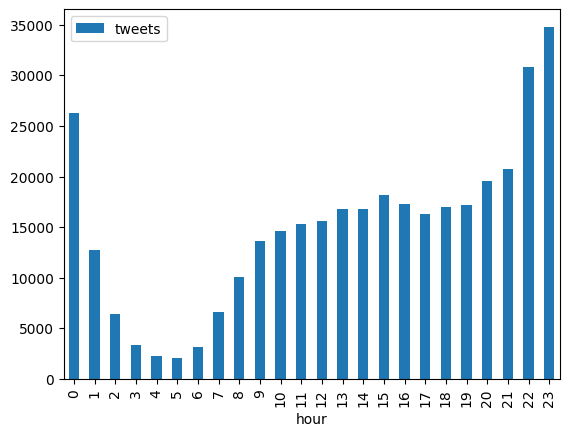

In [44]:
from pyspark.sql.functions import col, hour, date_format, avg, count

seed = 42
fraction = 0.01
tweets_sample = tweets.sample(withReplacement=None, fraction=fraction, seed=seed) # [22]
print("Number of tweets sampled: {0}".format(tweets_sample.count()))

tweets_timestamp = (
    tweets_sample
        .withColumn("hour", hour(col("created_at"))) # [23]
        .withColumn("day", date_format(col("created_at"), "MM-dd-yy")) # [24] 
        .select("created_at", "hour", "day")  # agafem nomes les 3 columnes que ens interessen
        .orderBy("created_at", ascending=True)
)

print("Primeres files de tweets_timestamp:")
tweets_timestamp.show(10)

tweets_hour_day = (
    tweets_timestamp
        .groupBy("day", "hour")  # agrupem per dia i hora
        .agg(count("*").alias("tweets")) # comptem de files (=nombre de tweets)
        .orderBy("day", "hour") # ordenem per fer més fàcil la lectura
)

print("Primeres files de tweets_hour_day:")
tweets_hour_day.show(10)

tweets_hour = (
    tweets_hour_day
        .groupBy("hour")  # sera la primera columna
        .agg((avg("tweets")*100).alias("tweets"))  # agreguem el comptatge per hora (amb el nombre ajustat al 100% dels tweets) i canviem el nombre de la columna
        .orderBy("hour", ascending=True)
)
print("Tweets per hora (estimació 100% dels tweets):")
tweets_hour.show(24)
tweets_hour_pd = tweets_hour.toPandas()
tweets_hour_pd.plot.bar(x='hour', y='tweets') # [25]

In [32]:
# DO NOT USE THIS CELL

### Estratificat

En moltes ocasions el mostreig homogeni no és adequat ja que per la pròpia estructura de les dades determinats segments poden estar sobre-representades. Aquest és el cas que observem en els tweets on les grans àrees urbanes estan sobrerepresentades si ho comparem amb el volum de població. En aquesta activitat veurem com aplicar aquesta tècnica al dataset de tweets, per obtenir un mostreig que respecti la proporció de diputats per província.

A Espanya, el procés electoral assigna un volum de diputats a cada província que depèn de la població i d'un percentatge mínim assignat per llei. En el context Hive que hem creat prèviament (```hiveContext```) podem trobar una taula (```province_28a```) que conté informació sobre les circumscripcions electorals. Carregueu aquesta taula en una variable amb nom ```province```.

In [33]:
province = spark.table("province_28a")
province.limit(20).show()

+-----------+-----------+------------------+----------+---------+
|    capital|   province|              ccaa|population|diputados|
+-----------+-----------+------------------+----------+---------+
|     Teruel|     Teruel|            Aragón|     35691|        3|
|      Soria|      Soria|   Castilla y León|     39112|        2|
|    Segovia|    Segovia|   Castilla y León|     51683|        3|
|     Huesca|     Huesca|            Aragón|     52463|        3|
|     Cuenca|     Cuenca|Castilla-La Mancha|     54898|        3|
|      Ávila|      Ávila|   Castilla y León|     57697|        3|
|     Zamora|     Zamora|   Castilla y León|     61827|        3|
|Ciudad Real|Ciudad Real|Castilla-La Mancha|     74743|        5|
|   Palencia|   Palencia|   Castilla y León|     78629|        3|
| Pontevedra| Pontevedra|           Galicia|     82802|        7|
|     Toledo|     Toledo|Castilla-La Mancha|     84282|        6|
|Guadalajara|Guadalajara|Castilla-La Mancha|     84910|        3|
|      Ceu

In [34]:
assert province.count() == 52, "Incorrect answer"

Per fer un mostreig estratificat, primer hem de determinar la fracció que volem assignar a cada categoria. En aquest cas, volem una fracció que faci que la ràtio tweets per diputat sigui igual per a totes les capitals de província. Hem de tenir en compte que la precisió de la geolocalització a Twitter és normalment a nivell de ciutat. Per això, per evitar incrementar la complexitat de l'exercici, utilitzarem els tweets en capitals de província com a proxy dels tweets en tota la província.

### **Exercici 8**: Anàlisi de la Relació entre Tweets i Diputats per Província (*0.75 punts*)

El primer que heu de fer és crear una taula ```info_tweets_province``` que ha de contenir:
- ***capital:*** nom de la capital de província.
- ***tweets:*** nombre de tweets geolocalitzats en cada capital.
- ***diputats:*** diputats assignats a la província.
- ***ratio_tweets_diputat:*** nombre de tweets per diputat.

Heu d'ordenar la llista per ```ratio_tweets_diputado``` en ordre ascendent.

***Nota:*** Podeu realitzar aquest exercici de moltes maneres, probablement la més fàcil és utilitzar la taula ```tweets_place``` que heu generat en l'exercici 5. Recordeu com utilitzar el ```join()```.

ACABAR DE COMENTAR -------------------------------------------------------[[26]](https://sparkbyexamples.com/pyspark/pyspark-join-explained-with-examples/)

In [35]:
info_tweets_province = (
    tweets_place.join(province, tweets_place.name == province.capital, "inner") # [26]
        .select(
            province.capital,
            tweets_place.tweets,
            province.diputados,
            (tweets_place.tweets / province.diputados).alias("ratio_tweets_diputado")
        )
        .orderBy("ratio_tweets_diputado", ascending=True)
)

print("Primeres files de info_tweets_province:")
info_tweets_province.show(10)

Primeres files de info_tweets_province:


[Stage 61:==================================================>       (7 + 1) / 8]

+-----------+------+---------+---------------------+
|    capital|tweets|diputados|ratio_tweets_diputado|
+-----------+------+---------+---------------------+
|     Teruel|     8|        3|   2.6666666666666665|
| Pontevedra|    29|        7|    4.142857142857143|
|     Zamora|    23|        3|    7.666666666666667|
|     Huesca|    26|        3|    8.666666666666666|
|    Segovia|    28|        3|    9.333333333333334|
|      Cádiz|   108|        9|                 12.0|
|      Soria|    25|        2|                 12.5|
|     Cuenca|    39|        3|                 13.0|
|Ciudad Real|    67|        5|                 13.4|
|       Lugo|    56|        4|                 14.0|
+-----------+------+---------+---------------------+
only showing top 10 rows



In [36]:
# VARIABLES DADAS
output = info_tweets_province.first()
maximum_ratio = floor(output.ratio_tweets_diputado * 100) / 100

In [37]:
# DO NOT USE THIS CELL

A continuació, necessitem un diccionari amb el nom ```ratios``` on cada capital de província és una clau i el seu valor associat és la fracció de tweets que anem a mostrejar. En aquest cas, el que volem és que la ràtio de tweets per cada diputat sigui similar per a cada capital de província.

Com que volem que el mostreig sigui el més gran possible i no volem que cap capital estigui infrarepresentada, la ràtio de tweets per diputat serà el valor més petit que podeu observar a la taula ```info_tweets_province```, que correspon a 2.66 tweets per diputat a Teruel. Teniu aquest valor guardat a la variable ```maximum_ratio```.

*Nota:* El mètode ```collectAsMap()``` transforma un PairRDD en un diccionari.

Finalment, genera una taula ```geo_tweets``` amb tots els tweets geolocalitzats. Ara ja estem en disposició de fer el mostreig estratificat per població. Per a això podeu utilitzar el mètode ```sampleBy()```. Utilitzeu 42 com a llavor del generador pseudoaleatori.

L'objectiu en aquest cas, es quedar-nos en una proporció de tweets/diputats = 2.66 per totes les províncies (a diferència de la ratio_tweets_diputado calculada abans). Tenint en compte que $tweets·fracció/diputats = 2.66$, aleshores la fracció de tweets que cal mostrejar de cada província pot calcular-se com $2.66·diputats/tweets$, o el que és el mateix, $maximum_{ratio}·diputats/tweets$. Així, per tal de calcular-ho per totes les províncies, ho passem a rdd, a través de map() i lambda calculem les ratios, i donat que ens retornarà tuples, podem passar-les a diccionari mitjançant collectAsMap() [[27]](https://www.skytowner.com/explore/pyspark_rdd_collectasmap_method).

Finalment, creem geo_tweets (mateix que tweets_geo de l'exercici 5), i fem un mostreig amb sampleby() [[28]](https://sparkbyexamples.com/pyspark/explain-sampleby-function-in-pyspark/), indicant que el mostreig es sobre la columna name (província) i les fraccions a afagar de cada una són les calculades (ratios). 

In [38]:
ratios = info_tweets_province.rdd.map(lambda x: (x['capital'], (maximum_ratio * x['diputados']) / x['tweets'])).collectAsMap()  # [27]

print("Ratios calculades:")
print(ratios)

# creem geo_tweets (mateix que tweets_geo de l'exercici 5)
geo_tweets = spark.sql(''' 
    SELECT
        place.name AS name,
        text
    FROM tweets28a_sample25
    WHERE place IS NOT NULL AND
          place.name IS NOT NULL
''')

# Generem un mostreig estratificat segons les ratios calculades
geo_tweets_sampled = geo_tweets.sampleBy(col="name", fractions=ratios, seed=42) # [28]

print("Primeres files (estratificat):")
geo_tweets_sampled.show(10)

Ratios calculades:
{'Teruel': 0.9975, 'Pontevedra': 0.6420689655172415, 'Zamora': 0.34695652173913044, 'Huesca': 0.30692307692307697, 'Segovia': 0.28500000000000003, 'Cádiz': 0.22166666666666668, 'Soria': 0.21280000000000002, 'Cuenca': 0.20461538461538462, 'Ciudad Real': 0.1985074626865672, 'Lugo': 0.19, 'Pamplona': 0.17272727272727273, 'Jaén': 0.15465116279069768, 'Guadalajara': 0.14250000000000002, 'Cáceres': 0.14186666666666667, 'Santa Cruz de Tenerife': 0.133, 'Toledo': 0.12870967741935485, 'Albacete': 0.12819277108433735, 'San Sebastián': 0.12566929133858268, 'Palencia': 0.1191044776119403, 'Tarragona': 0.11822222222222223, 'Almería': 0.11649635036496352, 'Castellón de la Plana': 0.10991735537190084, 'Badajoz': 0.10857142857142858, 'Vitoria-Gasteiz': 0.10133333333333334, 'Logroño': 0.10133333333333334, 'Bilbao': 0.09457777777777779, 'Huelva': 0.09047619047619049, 'Ávila': 0.0876923076923077, 'León': 0.0865040650406504, 'Burgos': 0.08184615384615385, 'Alicante': 0.07842751842751843

[Stage 77:>                                                         (0 + 1) / 1]

+--------------------+--------------------+
|                name|                text|
+--------------------+--------------------+
|              Madrid|Como bien dices @...|
|               Cádiz|Recordáis el dich...|
|              Girona|@LauraBorras Precios|
|           Barcelona|@ComptadorRep @jo...|
|              Madrid|@Pablo_Iglesias_ ...|
|            Valencia|https://t.co/iJI9...|
|Santa Cruz de Ten...|@ahorapodemos @Ir...|
|             Cáceres|@ostinus77 @swap1...|
|              Málaga|@JavierMaroto mie...|
|              Oviedo|@codificado03 @Vo...|
+--------------------+--------------------+
only showing top 10 rows



In [39]:
# DO NOT USE THIS CELL

## Introducció a les dades relacionals

El fet de treballar amb una base de dades que conté informació generada en una xarxa social ens permet introduir el concepte de dades relacionals. Podem definir dades relacionals com aquelles en què existeixen relacions entre les entitats que constitueixen la base de dades. Si aquestes relacions són binàries, relacions 1 a 1, podem representar les relacions com un graf compost per un conjunt de vèrtexs $\mathcal{V}$ i un conjunt d'arestes $\mathcal{E}$ que els relacionen.

En el cas de grafs que emergeixen de manera orgànica, aquest tipus d'estructura va més enllà dels grafs regulars que segurament coneixeu. Aquest tipus d'estructures es coneixen com a [xarxes complexes](https://ca.wikipedia.org/wiki/Xarxa_complexa). L'estudi de l'estructura i dinàmiques d'aquest tipus de xarxes ha contribuït a importants resultats en camps tan dispars com la física, la sociologia, l'ecologia o la medicina.

![complex_network](https://images.squarespace-cdn.com/content/5150aec6e4b0e340ec52710a/1364574727391-XVOFAB9P6GHKTDAH6QTA/lastfm_800_graph_white.png?content-type=image%2Fpng)

En aquesta última part de la pràctica treballarem amb aquest tipus de dades. En concret modelarem una de les possibles relacions presents en el dataset, la xarxa de retweets.

#### Construcció de l'edgelist

El primer que se us demana és que genereu la xarxa. Hi ha diverses maneres de representar una xarxa complexa, per exemple, si estiguéssiu interessats a treballar-hi des del punt de vista teòric, la manera més habitual de representar-les és utilitzant una [matriu d'adjacència](https://ca.wikipedia.org/wiki/Matriu_d%27adjacència). En aquesta pràctica ens centrarem en l'aspecte computacional, una de les maneres més eficients (computacionalment parlant) de representar una xarxa és mitjançant la seva [*edge list*](https://en.wikipedia.org/wiki/Edge_list), una taula que especifica la relació a parelles entre les entitats.

Les relacions poden ser bidireccionals o direccionals i tenir algun pes assignat o no (weighted or unweighted). En el cas que ens ocupa, estem parlant d'una xarxa dirigida, un usuari retuiteja a un altre, i podem pensar-la tenint en compte quantes vegades això ha passat.

#### Centralitat de grau

Un dels descriptors més comuns en l'anàlisi de xarxes és el grau. El grau quantifica quantes arestes estan connectades a cada vèrtex~s~. En el cas de xarxes dirigides com la que acabem de crear aquest descriptor està descompost en el:
- **in degree**: quantes arestes apunten al node
- **out degree**: quantes arestes surten del node

Si fas un rànquing d'aquests valors obtindràs una mesura de centralitat, la [centralitat de grau](https://en.wikipedia.org/wiki/Centrality#Degree_centrality), de cadascun dels nodes.

### **Exercici 9**: Anàlisi d'Interaccions de Retweets i Graus d'Usuari (*0.5 punts*)

A partir d'una mostra homogènia de l'1% dels tweets, amb la llavor 42 per garantir la reproductibilitat, realitza una anàlisi de les interaccions de retweets entre usuaris a la xarxa social.

**Esquema**
```Python
seed = 42
sample = tweets.<FILL IN>
```
Crea una taula ```edgelist``` amb la següent informació:
- ***src:*** usuari que retuiteja
- ***dst:*** usuari que és retuitejat
- ***weight:*** nombre de vegades que un usuari retuiteja a un altre.

Filtra el resultat perquè contingui només les relacions amb un weight igual o superior a dos.

A continuació, genera una taula `outDegree` amb la informació:
- ***screen_name:*** nom de l'usuari.
- ***outDegree:*** out degree del node.

Ordena la taula per out degree en ordre descendent.

Se us demana ara que genereu una taula `inDegree` amb la informació:
- ***screen_name:*** nom de l'usuari.
- ***inDegree:*** in degree del node.

Ordena la taula per in degree en ordre descendent.

En primer lloc, cal tenir clar que son els nostres vertexs i arestes. Tenint en compte la relacio A -> B, on A es la persona que retuiteja a B, aleshores A és src i B és dst, segons l'exercici (ambdós són vertexs). Això implica que outDegree contindrà usuaris que retuitegen i nombre de tweets retuitejats, mentre que inDegree contindrà els usuaris B (retwuitejats) i el nombre de tuits retuitejats per usuaris A. Les arestes són la relació entre nodes/vertexs. 

Tot i que hem creat una sample de 1% de tweets a l'exercici 7, la tornem a crear sota el nom de sample per completitud d'aquest exercici. També la registrem com a taula SQL mitjançant createOrReplaceTempView() per poder treballar amb queries SQL si ho requerim. Un cop creada la taula "sample", podem crear edgelist. Per fer-ho, i donat que l'exercici no requereix fer ús de funcions pipeline de spark, hem utilitzat spark.sql(query), creant la query adequada per tal d'obtenir la taula en el format demanat. 

A partir del DataFrame edgelist obtingut, hem creat (ara sí amb funcions pipeline) les taules outDegree i inDegree. Per outDegree, hem agrupat segons el nom d'usuari que retuiteja i hem comptat tots els usuaris que han estat retuitejats (no el nombre de tuits, sinó hauriem de tenir en compte weight, i només se'ns demana el nombre de connexions (B) de l'usuari A). De forma similar, per inDegree hem agrupat segons l'usuari que ha estat retuitejat, i hem comptat el nombre d'usuaris que ho han fet (de nou, no el nombre de tuits). Ambdues taules s'han ordenat descendentment. 

ACABAR DE COMENTAR QUAN SAPIGUEM RESPOSTA ---------------------------------------------------------------------------------(IF NECESSARY)

In [42]:
# ja creada anteriorment amb el nom de tweets_sample a l'exercici 7, pero repetim per completitud de l'exercici 9
seed = 42
fraction = 0.01
sample = tweets.sample(withReplacement=None, fraction=fraction, seed=seed)
sample.createOrReplaceTempView("sample")  # si volem treballar amb SQL aleshores cal registrar la taula sample com taula SQL
sample.printSchema()

# creem la taula edgelist amb una query SQL
query = '''
    SELECT
        user.screen_name AS src,
        retweeted_status.user.screen_name AS dst,
        COUNT(*) AS weight
    FROM sample
    WHERE retweeted_status IS NOT NULL
    GROUP BY user.screen_name, retweeted_status.user.screen_name
    HAVING COUNT(*) >= 2
'''

print("Primeres linies de edgelist:")
edgelist = spark.sql(query)
edgelist.show(10)

outDegree = (
    edgelist
    .groupBy("src")
    .agg(count("dst").alias("outDegree"))
    .withColumnRenamed("src", "screen_name")
    .orderBy(col("outDegree").desc())
)

print("Primeres linies de outDegree:")
outDegree.show(10)

inDegree = (
    edgelist
    .groupBy("dst") 
    .agg(count("src").alias("inDegree"))
    .withColumnRenamed("dst", "screen_name")
    .orderBy(col("inDegree").desc())
)

print("Primeres linies de inDegree:")
inDegree.show(10)

root
 |-- _id: string (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- lang: string (nullable = true)
 |-- place: struct (nullable = true)
 |    |-- bounding_box: struct (nullable = true)
 |    |    |-- coordinates: array (nullable = true)
 |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |    |-- element: double (containsNull = true)
 |    |    |-- type: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- place_type: string (nullable = true)
 |-- retweeted_status: struct (nullable = true)
 |    |-- _id: string (nullable = true)
 |    |-- user: struct (nullable = true)
 |    |    |-- followers_count: long (nullable = true)
 |    |    |-- friends_count: long (nullable = true)
 |    |    |-- id_str: string (nullable = true)
 |    |    |-- lang: string (nullable = true)
 

+---------------+-------------+------+
|            src|          dst|weight|
+---------------+-------------+------+
|   Socialista60|    Nachoanon|     2|
|TopTradingBolsa| ahorapodemos|     3|
|lajusticieracat|gabrielrufian|     2|
|     manolivi64|  protestona1|     2|
|      maynake84| Pacma_Madrid|     2|
| margaritafontr|    josepalay|     2|
|Antonio84960717|     ivanedlm|     2|
|     EloyValMar| CiudadanosCs|     2|
|  Pdemocratacat|    JuntsXCat|     5|
|daniiglesias_cs| CiudadanosCs|     2|
+---------------+-------------+------+
only showing top 10 rows

Primeres linies de outDegree:


+---------------+---------+
|    screen_name|outDegree|
+---------------+---------+
| soniapillado70|        3|
|     carrasquem|        2|
|   TorrijosMari|        2|
|miguelgutiperez|        2|
|FRANCIS67590251|        2|
|    CsCartagena|        2|
| Perona10690463|        2|
|    mariaje1956|        2|
|      rsarille4|        2|
|      Zibelinam|        2|
+---------------+---------+
only showing top 10 rows

Primeres linies de inDegree:


[Stage 87:==================================================>       (7 + 1) / 8]

+---------------+--------+
|    screen_name|inDegree|
+---------------+--------+
|           PSOE|      44|
|   CiudadanosCs|      36|
|         vox_es|      32|
|   ahorapodemos|      29|
|      populares|      17|
|  AlbanoDante76|       9|
|  Santi_ABASCAL|       8|
|       ivanedlm|       7|
|Front_Republica|       7|
|Pablo_Iglesias_|       7|
+---------------+--------+
only showing top 10 rows



In [ ]:
# DO NOT USE THIS CELL

### **Exercici 10**: Distribució del Grau de Sortida en una Xarxa de Retweets (*0.5 punts*)

A partir d'una mostra de l'1% dels tweets, amb una llavor de 42 per assegurar la reproductibilitat, realitza una anàlisi bàsica de la xarxa de retweets. El teu objectiu és calcular i mostrar la distribució de graus dels usuaris en la xarxa de retweets.

Per a això, segueix aquests passos:

- Crea una taula de Edgelist: Defineix una taula `edgelist` que contingui les relacions de retweet entre usuaris, on cada fila representa un retweet realitzat d'un usuari a un altre.

- Calcula el Grau de Sortida (Out-Degree): Determina quants retweets ha realitzat cada usuari (és a dir, el nombre d'usuaris als quals cada usuari ha retuitejat). Anomena aquesta variable `outDegree`.

- Obté la Distribució de Grau de Sortida: Crea una taula `outDegree_distribution` que mostri quants usuaris tenen un determinat nombre de retweets realitzats. Ordena els resultats pel grau de sortida.

En aquest exercici, no podem utilitzar les taules creades en l'exercici 9, ja que per exemple edgelist contenia diversos tuits en una sola fila, mentre que ara cada tuit ha de ser una fila. Per fer-ho, utilitzem la query anterior adaptada per tal de no agrupar segons usuaris.

ACABAR DE COMENTAR QUAN SAPIGUEM RESPOSTA ---------------------------------------------------------------------------------

In [ ]:
edgelist = spark.sql('''
    SELECT
        user.screen_name AS src,
        retweeted_status.user.screen_name AS dst
    FROM sample
    WHERE retweeted_status IS NOT NULL
''')

edgelist.show(10)



In [ ]:
# DO NOT USE THIS CELL

### **Exercici 11**: Preguntes teòriques (*2.5 punts*)

Durant l'entrevista final amb cada grup, que es realitzarà mitjançant videotrucada, es revisarà breument la pràctica realitzada.

A la darrera part de l'entrevista es plantejaran 4 preguntes teòriques relacionades amb els continguts de la pràctica i del temari vist fins ara (Des del mòdul 1, fins al mòdul 4).

- Cada pregunta tindrà una puntuació de 0,625 punts.

- Les preguntes es respondran oralment durant l'entrevista.

- Es valorarà la comprensió dels conceptes teòrics i la capacitat d'explicar-los amb claredat.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()